In [1]:
import numpy as np
from scipy.interpolate import CubicSpline
import math
import matplotlib.pyplot as plt
import matplotlib as mpl





In [2]:
with open('./zr.nff','r') as file:
        k = 0
        eVV, f11, f22 = [], [], []
        for line in file.readlines():
            if k==0:
                k = 1
            else:
                index1 = line.find('\t')
                eVV.append(float(line[0:index1]))
                index2 = line.find('\t',index1+1)
                f11.append(float(line[(index1+1):index2]))
                f22.append(float(line[(index2+1):]))
for i in range(len(eVV)-1):
     i = i+1
     if eVV[i]<eVV[i-1]:
        print("不是递增点：{}".format(i))
eV, f1, f2 = [], [], []
for i in range(len(f11)):
    if f11[i] >-500:
        eV.append(eVV[i])
        f1.append(f11[i])
        f2.append(f22[i])
#for1 = CubicSpline(eV,f1)
#for2 = CubicSpline(eV,f2)
Re_sld = [f1[i]*(19.32/196.9666*6.02214076e23)*1e6*2.8179403e-15*1e-20 for i in range(len(f1))]
Im_sld = [f2[i]*(19.32/196.9666*6.02214076e23)*1e6*2.8179403e-15*1e-20 for i in range(len(f2))]
delta, beta = [], []
for i in range(len(eV)):
    delta.append(Re_sld[i]*np.power(12398.41984/eV[i],2)/2/np.pi)
    beta.append(Im_sld[i]*np.power(12398.41984/eV[i],2)/2/np.pi)


In [3]:
eV_input = list(np.linspace(30,30000,10001))
Re_input1, Im_input1 = [], []
Re_input2, Im_input2 = [], []


In [4]:
#线性插值和对数插值
for i in range(len(eV_input)):
        k = 0
        for index,num in enumerate(eV):
            if index==0:
                if eV_input[i]==num:
                    Re_input1.append(Re_sld[index])
                    Im_input1.append(Im_sld[index])
                    k = 1
                    break
            elif eV_input[i]==num:
                Re_input1.append(Re_sld[index])
                Im_input1.append(Im_sld[index])
                k = 1
                break
            elif eV_input[i]<num and eV_input[i]>eV[index-1]:
                liner_Re = Re_sld[index-1]+(Re_sld[index]-Re_sld[index-1])/(num-eV[index-1])*(eV_input[i]-eV[index-1])
                #log_Im = Im_sld[index-1]+(Im_sld[index]-Im_sld[index-1])/(num-eV[index-1])*(eV_input[i]-eV[index-1])
                log_Im = np.exp(np.log(Im_sld[index-1])+(np.log(Im_sld[index])-np.log(Im_sld[index-1]))/(num-eV[index-1])*(eV_input[i]-eV[index-1])) 
                Re_input1.append(liner_Re)
                Im_input1.append(log_Im)
                k = 1
                break
        if k==0:
            Re_input1.append(-9999.0)
            Im_input1.append(-9999.0)
delta1, beta1 = [], []
for i in range(len(eV_input)):
    delta1.append(Re_input1[i]*np.power(12398.41984/eV_input[i],2)/2/np.pi)
    beta1.append(Im_input1[i]*np.power(12398.41984/eV_input[i],2)/2/np.pi)


print(eV_input)
print(delta1)
print(beta1)



[30.0, 32.997, 35.994, 38.991, 41.988, 44.985, 47.982, 50.979, 53.976, 56.973, 59.97, 62.967, 65.964, 68.961, 71.958, 74.955, 77.952, 80.949, 83.946, 86.943, 89.94, 92.937, 95.934, 98.931, 101.928, 104.925, 107.922, 110.919, 113.916, 116.913, 119.91, 122.907, 125.904, 128.901, 131.898, 134.89499999999998, 137.892, 140.889, 143.886, 146.88299999999998, 149.88, 152.877, 155.874, 158.87099999999998, 161.868, 164.865, 167.862, 170.85899999999998, 173.856, 176.853, 179.85, 182.84699999999998, 185.844, 188.841, 191.838, 194.83499999999998, 197.832, 200.829, 203.826, 206.82299999999998, 209.82, 212.817, 215.814, 218.81099999999998, 221.808, 224.805, 227.802, 230.79899999999998, 233.796, 236.793, 239.79, 242.78699999999998, 245.784, 248.781, 251.778, 254.77499999999998, 257.772, 260.769, 263.76599999999996, 266.763, 269.76, 272.757, 275.754, 278.751, 281.748, 284.745, 287.74199999999996, 290.739, 293.736, 296.733, 299.73, 302.727, 305.724, 308.721, 311.71799999999996, 314.715, 317.712, 320.709

C:\Users\Cbs\AppData\Local\Temp\ipykernel_34396\3898707563.py:10: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(eV, Im_sld, 'r-', color='#000003', alpha=0.5, linewidth=2, label='Im_sld')
C:\Users\Cbs\AppData\Local\Temp\ipykernel_34396\3898707563.py:12: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(eV_input, Im_input1, 'r-', color='#8A3BE2', alpha=0.5, linewidth=2, label='Im_log')


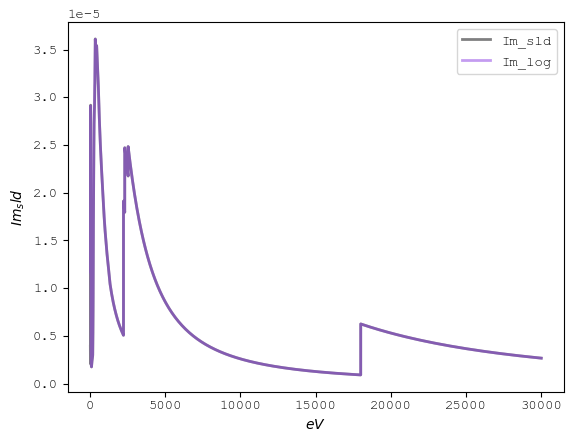

In [10]:
mpl.rcParams['font.family']='Courier New'       # 将字体指定为vscode字体，解决不能显示符号的问题
#plt.rcParams['axes.unicode_minus'] = False           # 解决保存图像是负号'-'显示为方块的问题
font = {'family': 'serif',
        'color':  'darkred',
        'weight': 'normal',
        'size': 8,
        }
# plot中参数的含义分别是横轴值, 纵轴值，线的形状，颜色，透明度,线的宽度和标签
#plt.plot(eV, Re_sld, 'r-', color='#32CD32', alpha=0.5, linewidth=2, label='Re_sld')
plt.plot(eV, Im_sld, 'r-', color='#000003', alpha=0.5, linewidth=2, label='Im_sld')
#plt.plot(eV_input, Re_input1, 'r-', color='#C13345', alpha=0.5, linewidth=2, label='Re_liner')
plt.plot(eV_input, Im_input1, 'r-', color='#8A3BE2', alpha=0.5, linewidth=2, label='Im_log')
#plt.plot(eV_input, Re_input2, 'r-', color='#45AB46', alpha=0.5, linewidth=2, label='Re_three')
#plt.plot(eV_input, Im_input2, 'r-', color='#4A6BE2', alpha=0.5, linewidth=2, label='Im_three')
plt.xlabel(r'$eV$')
plt.ylabel(r'$Im_sld$')
plt.legend()
plt.show()

In [6]:
Model_air = [['air',0.0, 0.0]]
Model_A=[
        ['mo', 27.6, 0.0],
        ['si', 41.4, 0.0],
    ]
Model_sub = [['mo',0.0, 0.0]]
period = 4
Model = Model_air+Model_A*period+Model_sub

In [7]:
Model = [['air',0.0, 0.0]]
mu_mo = 27.6
mu_si = 41.4
sigma = 1.0
rou = 0.0
period = 3
gua_mo = np.random.normal(mu_mo, sigma, period)
gua_si = np.random.normal(mu_si, sigma, period)
for i in range(0, period):
    Model = Model+[['mo', gua_mo[i], rou]]+[['si', gua_si[i], rou]]
Model = Model+[['mo', np.random.normal(mu_mo, sigma), rou]]+[['si', 0.0, 0.0]]
print(Model)


[['air', 0.0, 0.0], ['mo', 29.15213369289233, 0.0], ['si', 41.91045949396099, 0.0], ['mo', 28.07188741851492, 0.0], ['si', 40.30105813774729, 0.0], ['mo', 28.59036054451123, 0.0], ['si', 41.319475278494444, 0.0], ['mo', 27.60225750797167, 0.0], ['si', 0.0, 0.0]]


In [11]:
import re

formula = '0.4SCoO+0.1Al2O3+0.2Si3N4+0.3CuSO4'
formulas = re.split(r'\s*\+\s*',formula)


Material = {}
for formula in formulas:
    formula_num = re.search(r'^\b\d+\.*\d*[e\-]*\d*', formula)
    fuhao = re.search(r'%', formula)
    if fuhao!=None:
        if formula_num!=None:
            formula_num = float(formula_num.group())*0.01
        else:
            formula_num = 1
    else:
        if formula_num!=None:
            formula_num = float(formula_num.group())
        else:
            formula_num = 1
    formula_mat = re.findall(r'([A-Z][a-z]*)(\d*)', formula)
    for element, num in formula_mat:
        if num == '':
            num = 1*formula_num
        else:
            num = float(num)*formula_num
        if Material.get(element):
            Material[element] = num+Material[element]
        else:
            Material[element] = num
print(Material)

{'S': 0.7, 'Co': 0.4, 'O': 1.9, 'Al': 0.2, 'Si': 0.6000000000000001, 'N': 0.8, 'Cu': 0.3}


In [145]:
import re
p = re.compile(r'\d\+\d')
m = p.findall( '((((of 3.1 Lots many))' )
print(m)


[]


In [96]:
import re
m = re.findall("(\w+)", "abc tg a ga bd bc")
print(m)

#m = re.match("(?:[abc])+", "abc")
#m.groups()


['abc', 't', 'a', 'a', 'b', 'bc']


In [99]:
import re

# 条件匹配
pattern = r'(abc)|(def)'
text = 'abcdef'
match = re.search(pattern, text)

if match:
    print(f"Match: {match.group()}")  # abc

Match: abc


In [3]:
new_dict = {'o':[23,44], 'G':[3,3.5], 'M':[2,4.3]}
print(new_dict.items())
print(new_dict)

dict_items([('o', [23, 44]), ('G', [3, 3.5]), ('M', [2, 4.3])])
{'o': [23, 44], 'G': [3, 3.5], 'M': [2, 4.3]}


In [40]:
import re
import sys

with open('./siii.nff','r') as file:
            k = 0
            eVV, f11, f22 = [], [], []
            for line in file.readlines():
                if k==0:
                    k = 1
                else:
                    num = re.findall(r'[\+\-]*\d+\.*\d*[Ee\-\+]*\d*', line)
                    eVV.append(float(num[0]))
                    f11.append(float(num[1]))
                    f22.append(float(num[2]))
eV, f1, f2 = [], [], []
for i in range(len(f11)):
    if f11[i] >-500:
        eV.append(eVV[i])
        f1.append(f11[i])
        f2.append(f22[i])
for a, b, c in zip(eVV,f11,f22):
    print(f"{a:15}{b:10}{c:10}")
                    

           29.3   -3.8338   37.1749
  29773000000.0   0.38069  0.372851
        30.2554   3.78097  0.373956
        30.7448   3.75582  0.375064
        31.2421   3.73048  0.376176
        31.7474    3.7055  0.378088
        32.2609   3.68147  0.381996
        32.7827   3.65905  0.385945
        33.3129   3.63764  0.389935
        33.8517   3.61703  0.393965
        34.3992   3.59711  0.398038
        34.9556   3.57779  0.402152
         35.521     3.559  0.406309
        36.0955   3.54071  0.410509
        36.6793   3.52286  0.414753
        37.2726   3.50545   0.41904
        37.8754   3.48848  0.423372
         38.488     3.472  0.427748
        39.1106   3.45628   0.43217
        39.7431   3.44176  0.435537
         40.386   3.42689  0.437136
        41.0392    3.4105  0.438741
        41.7029   3.39378  0.440351
        42.3774   3.37667  0.441968
        43.0629   3.35917   0.44359
        43.7594    3.3413  0.445218
        44.4671   3.32304  0.446852
        45.1864    3.3044  0

In [31]:
with open('./siii.nff','r') as file:
        k = 0
        eVV, f11, f22 = [], [], []
        for line in file.readlines():
            if k==0:
                k = 1
            else:
                index1 = line.find('\t')
                eVV.append(float(line[0:index1]))
                index2 = line.find('\t',index1+1)
                f11.append(float(line[(index1+1):index2]))
                f22.append(float(line[(index2+1):]))

for i in range(len(eVV)-1):
     i = i+1
     if eVV[i]<eVV[i-1]:
        print("不是递增点：{}".format(i))
eV, f1, f2 = [], [], []
for i in range(len(f11)):
    if f11[i] >-500:
        eV.append(eVV[i])
        f1.append(f11[i])
        f2.append(f22[i])
for a, b, c in zip(eV,f1,f2):
    print(f"{a:10}{b:10}{c:10}")

      29.3    3.8338  0.371749
   29.7739   3.80691  0.372851
   30.2554   3.78097  0.373956
   30.7448   3.75582  0.375064
   31.2421   3.73048  0.376176
   31.7474    3.7055  0.378088
   32.2609   3.68147  0.381996
   32.7827   3.65905  0.385945
   33.3129   3.63764  0.389935
   33.8517   3.61703  0.393965
   34.3992   3.59711  0.398038
   34.9556   3.57779  0.402152
    35.521     3.559  0.406309
   36.0955   3.54071  0.410509
   36.6793   3.52286  0.414753
   37.2726   3.50545   0.41904
   37.8754   3.48848  0.423372
    38.488     3.472  0.427748
   39.1106   3.45628   0.43217
   39.7431   3.44176  0.435537
    40.386   3.42689  0.437136
   41.0392    3.4105  0.438741
   41.7029   3.39378  0.440351
   42.3774   3.37667  0.441968
   43.0629   3.35917   0.44359
   43.7594    3.3413  0.445218
   44.4671   3.32304  0.446852
   45.1864    3.3044  0.448493
   45.9172   3.28549  0.450139
   46.6599   3.26615  0.451198
   47.4146   3.24599  0.451979
   48.1815   3.22476  0.452762
   48.96

In [7]:
dict1 = {'Air':[2,3], 'Fe':[3.45, 5.78], 'Al':[5.7, 2.89]}
dict2 = list(dict1.items())
print(dict2[0])

('Air', [2, 3])


C:\Users\Cbs\AppData\Local\Temp\ipykernel_17976\2535264846.py:51: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(eV, f1, 'r-', color='#000003', alpha=0.5, linewidth=2, label='Henke_f1')
C:\Users\Cbs\AppData\Local\Temp\ipykernel_17976\2535264846.py:52: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(eV, f2, 'r-', color='#C13345', alpha=0.5, linewidth=2, label='Henke_f2')
C:\Users\Cbs\AppData\Local\Temp\ipykernel_17976\2535264846.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(eVn, f1n, 'r-', color='#8A3BE2', alpha=0.5, linewidth=2, label='Ratb_f1')
C:\Users\Cbs\AppData\Local\Temp\ipykernel_17976\2535264846.py:54: UserWarning:

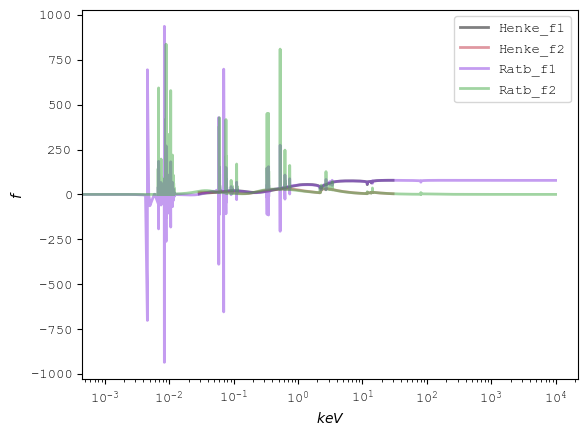

In [10]:
import re
import sys
import matplotlib as mpl
import matplotlib.pyplot as plt
#Henke
name = 'au'
with open(f'./{name}.nff','r') as file:
            k = 0
            eVV, f11, f22 = [], [], []
            for line in file.readlines():
                if k==0:
                    k = 1
                else:
                    num = re.findall(r'[\+\-]*\d+\.*\d*[Ee\-\+]*\d*', line)
                    eVV.append(float(num[0])/1000)
                    f11.append(float(num[1]))
                    f22.append(float(num[2]))
eV, f1, f2 = [], [], []
for i in range(len(f11)):
    if f11[i] >-500:
        eV.append(eVV[i])
        f1.append(f11[i])
        f2.append(f22[i])
#for a, b, c in zip(eVV,f11,f22):
    #print(f"{a:15}{b:10}{c:10}")


#NIST
with open(f'./{name}_RATB.txt','r') as file:
            k = 0
            eVVn, f11n, f22n = [], [], []
            for line in file.readlines():
                if k==0:
                    k = 1
                else:
                    num = re.findall(r'[\+\-]*\d+\.*\d*[Ee\-\+]*\d*', line)
                    eVVn.append(float(num[0]))
                    f11n.append(float(num[4]))
                    f22n.append(-float(num[1]))
eVn, f1n, f2n = [], [], []
for i in range(len(f11n)):
    if (f11n[i] >-1000) and (f22n[i]<1000) and (f11n[i] <1000):
        eVn.append(eVVn[i])
        f1n.append(f11n[i])
        f2n.append(f22n[i])
#for a, b, c in zip(eVVn,f11n,f22n):
    #print(f"{a:15.6e}{b:15.6e}{c:15.6e}")
mpl.rcParams['font.family']='Courier New'       # 将字体指定为vscode字体，解决不能显示符号的问题
plt.xscale('log')
#plt.yscale('log')
plt.plot(eV, f1, 'r-', color='#000003', alpha=0.5, linewidth=2, label='Henke_f1')
plt.plot(eV, f2, 'r-', color='#C13345', alpha=0.5, linewidth=2, label='Henke_f2')
plt.plot(eVn, f1n, 'r-', color='#8A3BE2', alpha=0.5, linewidth=2, label='Ratb_f1')
plt.plot(eVn, f2n, 'r-', color='#45AB46', alpha=0.5, linewidth=2, label='Ratb_f2')
plt.xlabel(r'$keV$')
plt.ylabel(r'$f$')

plt.legend()
plt.draw()                    

In [106]:
import numpy as np

a = np.exp(700+700j)
print(f'{a}')

(-8.510465045750563e+303+5.517123416261123e+303j)


NameError: name 'eV' is not defined

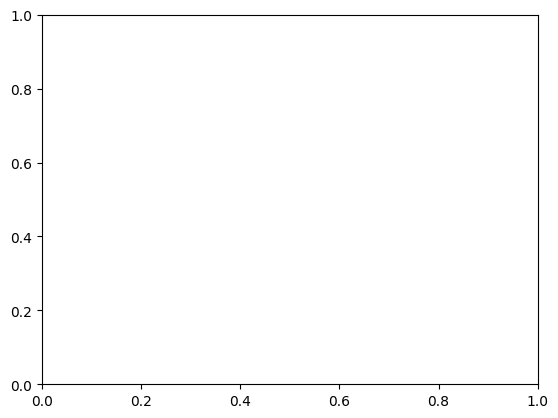

In [1]:
import matplotlib.pyplot as plt
import numpy as np



# 创建图形和轴域
fig, ax1 = plt.subplots()

# 绘制第一段数据
ax1.plot(eV, f1)
ax1.set_xlim(0.01, 1)
ax1.set_xscale('linear')  # 对数刻度

# 创建共享y轴的第二个轴域
ax2 = ax1.twinx()
ax2.plot(eVn, f1n)
ax2.set_xlim(1, 433)
ax2.set_xscale('log')  # 线性刻度

# 调整轴域的位置
#ax2.spines['right'].set_position(('outward', 60))  # 将第二个轴域向右移动

# 隐藏不必要的轴脊
#ax2.spines['left'].set_visible(False)
#ax1.spines['right'].set_visible(False)

# 显示图形
plt.show()



